<a href="https://colab.research.google.com/github/YoshnaM/6CS012-Artificial-Intelligence-and-Machine-Learning/blob/main/YoshnaMaharjan_2406791_Worksheet04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Worksheet 04

##Building a Fully Connected Network (FCN) for Devnagari Digit Classification

###Objective

In this exercise, you will build and train a Fully Connected Network (FCN) to classify Devnagari digits using TensorFlow and Keras. You will manually load and process the dataset using the Python Imaging Library (PIL) and then train the model with three hidden layers.

##Task 1: Data Preparation
###Loading the Data
*   Download the provided folder that contains the Devnagari digits dataset.
*   Use the Python Imaging Library (PIL) to load and read the image files from the dataset.
*   Convert the images into Numpy arrays and normalize them to a range of 0-1.
*   Use train folder for training and test for testing.

*   Extract the corresponding labels for each image.

###Hints:
*   Ensure that the images are resized to a consistent shape (e.g., 28x28).
*   Convert labels to one-hot encoded format for multi-class classification.

In [21]:
import os
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow import keras

In [22]:
zip_path = "/content/drive/MyDrive/Artificial_Intelligence_And_Machine_Learning/DevanagariHandwrittenDigitDataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print(os.listdir("/content/"))
print(os.listdir("/content/DevanagariHandwrittenDigitDataset"))

['.config', 'DevanagariHandwrittenDigitDataset', 'drive', 'devnagari_model.h5', 'sample_data']
['Test', 'Train']


In [23]:
# Paths
train_dir = "/content/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/DevanagariHandwrittenDigitDataset/Test/"

img_height, img_width = 28, 28

def load_images(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert("L")   # grayscale
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0               # normalize

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load data
x_train, y_train = load_images(train_dir)
x_test, y_test = load_images(test_dir)

# Reshape for CNN input
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (17000, 28, 28, 1) (17000, 10)
Test: (3000, 28, 28, 1) (3000, 10)


##Task 2: Build the FCN Model
###Model Architecture
*   Create a Sequential model using Keras.
*   Add 3 hidden layers with the following number of neurons:
    - 1st hidden layer: 64 neurons
    - 2nd hidden layer: 128 neurons
    - 3rd hidden layer: 256 neurons
*   Use sigmoid activation functions for all hidden layers.
*   Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a softmax activation function.

In [24]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    keras.layers.Flatten(),

    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),

    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Task 3: Compile the Model
###Model Compilation
*   Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy).

In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##Task 4: Train the Model
###Model Training
*   Use the model.fit() function to train the model. Set the batch size to 128 and the number of epochs to 20.
*   Use validation split (validation split=0.2) to monitor the model’s performance on validation data.
*   Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [27]:
from tensorflow import keras

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",  # save the best model
        monitor="val_loss",        # track validation loss
        save_best_only=True,       # save only if improved
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",        # stop if val_loss doesn't improve
        patience=3,                # wait 3 epochs before stopping
        verbose=1,
        restore_best_weights=True  # restore the best model after stopping
    )
]

# Train the model
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7981 - loss: 0.6567
Epoch 1: val_loss improved from None to 8.40274, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8387 - loss: 0.5181 - val_accuracy: 0.0000e+00 - val_loss: 8.4027
Epoch 2/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9197 - loss: 0.2853
Epoch 2: val_loss did not improve from 8.40274
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9229 - loss: 0.2678 - val_accuracy: 0.0000e+00 - val_loss: 8.9455
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9435 - loss: 0.1978
Epoch 3: val_loss did not improve from 8.40274
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9466 - loss: 0.1858 - val_accuracy: 0.0000e+00 - val_loss: 9.3860
Epoch 4/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9569 - loss: 0.1484
Epoch 4: val_loss did not improve from 8.40274
107/107 ━━━━━━━

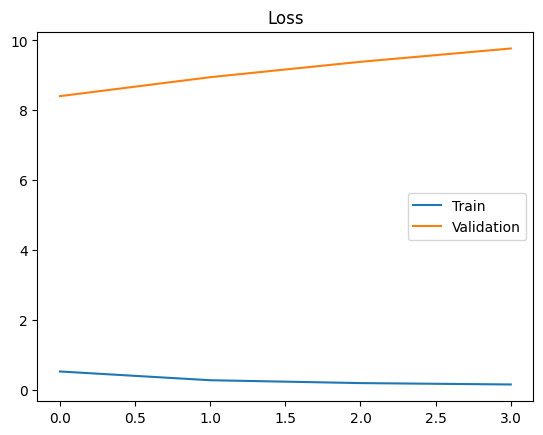

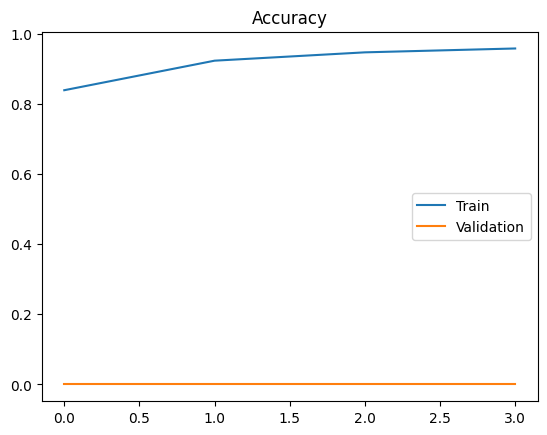

In [28]:
# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

##Task 5: Evaluate the Model
###Model Evaluation
*   After training, evaluate the model using model.evaluate() on the test set to check the test accuracy and loss.

In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7203 - loss: 1.9532
Test Accuracy: 0.7203333377838135


##Task 6: Save and Load the Model
###Model Saving and Loading
*   Save the trained model to an .h5 file using model.save().
*   Load the saved model and re-evaluate its performance on the test set.

In [31]:
# Save
model.save("devnagari_model.h5")

# Load
loaded_model = keras.models.load_model("devnagari_model.h5")

# Evaluate again
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7203 - loss: 1.9532
Loaded Model Accuracy: 0.7203333377838135


##Task 7: Predictions
###Making Predictions
*   Use model.predict() to make predictions on test images.
*   Convert the model’s predicted probabilities to digit labels using np.argmax().

In [32]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", true_labels[0])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted: 0
Actual: 0


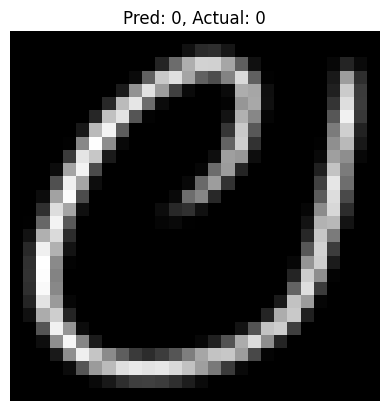

In [33]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Pred: {predicted_labels[0]}, Actual: {true_labels[0]}")
plt.axis("off")
plt.show()